In [35]:
import numpy as np
import pandas as pds
from zlib import crc32
import matplotlib.pyplot as plt
import csv
import sklearn.impute
from keras.src.ops import dtype
from matplotlib.pyplot import axis
from numpy.ma.extras import column_stack
from pandas.core.interchange.dataframe_protocol import DataFrame
from pandas.io.pytables import dropna_doc
from sklearn.impute import SimpleImputer
from fontTools.subset import subset
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
import seaborn as sns
from torch.nn.functional import relu
from sklearn.preprocessing import OrdinalEncoder

In [2]:
df=pds.read_csv(r'/OnAcademy')

In [3]:
df.info()
df=df.drop(20640)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20641 entries, 0 to 20640
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
(train_size,test_size) = train_test_split(df,test_size=0.2,random_state=0)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

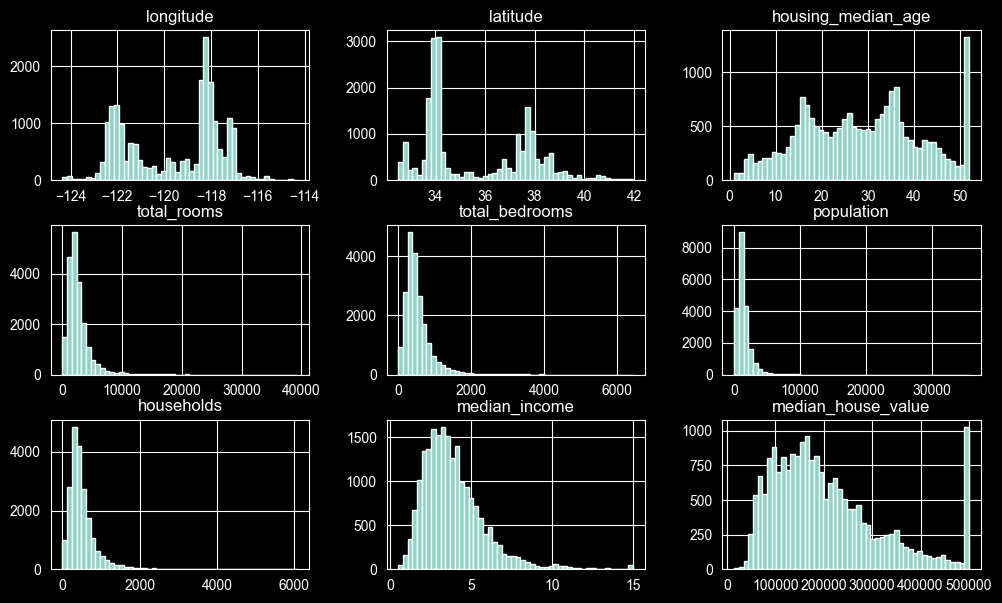

In [4]:
df.hist(bins=50,figsize=(12,7))

In [6]:
def shuffle_trian_test_split(df,test_ratio,random_state = 12):
    index=np.random.permutation(int(len(df)))
    test_size = index * test_ratio
    train_size = index - test_size
    return df.iloc[train_size],df.iloc[test_size]


In [7]:
train_size ,test_size = shuffle_trian_test_split(df,test_ratio=0.2)

In [8]:
test_size.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20640 entries, 1387 to 585
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20455 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [9]:
sss = StratifiedShuffleSplit(n_splits=10,test_size=0.2,random_state=10)

In [10]:
target = df["median_income"]

In [5]:
from pandas.core.interchange.dataframe_protocol import DataFrame


In [6]:
df = pds.DataFrame(df)

In [7]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [8]:
df["median_income_categories"] = pds.cut(df["median_income"],
                                        bins=[0, 2, 3.0, 4.5, 6.0, np.inf],
                                        labels=[1, 2, 3, 4, 5])

In [9]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_income_categories
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,2
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,1


In [10]:
df["median_income_categories"].isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
20635    False
20636    False
20637    False
20638    False
20639    False
Name: median_income_categories, Length: 20640, dtype: bool

In [11]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
X = np.array(df)
y = np.array(df["median_income_categories"])
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
sss.get_n_splits(X, y)

print(sss)

stratified_split = []
for train_i, test_i in sss.split(df, df["median_income_categories"]):
  train = df.iloc[train_i]
  test = df.iloc[test_i]
  stratified_split.append([train, test])

StratifiedShuffleSplit(n_splits=5, random_state=0, test_size=0.2,
            train_size=None)


In [12]:
train["ocean_proximity"] = df["ocean_proximity"]

C:\Users\Mobina\AppData\Local\Temp\ipykernel_7320\432612450.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train["ocean_proximity"] = df["ocean_proximity"]


In [13]:
train["median_income_categories"].value_counts()/len(train)

median_income_categories
3    0.350594
2    0.239644
4    0.176296
1    0.119004
5    0.114462
Name: count, dtype: float64

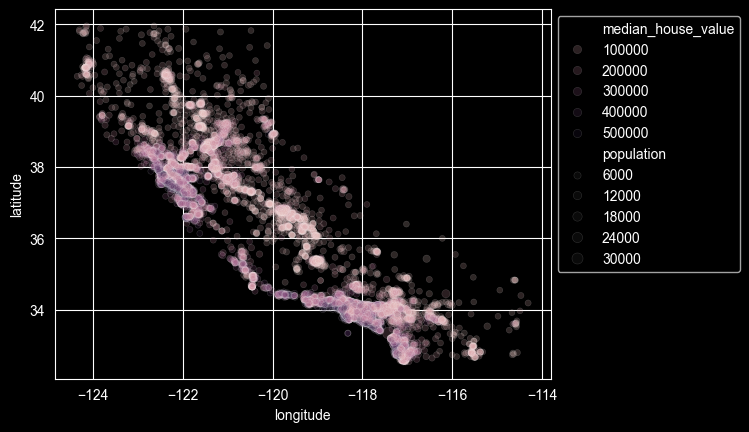

In [14]:
ax = sns.scatterplot(data=train,
                    x="longitude",
                    y="latitude",
                    size="population",
                    alpha=0.2,
                    hue="median_house_value")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 15477 to 10239
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 16512 non-null  float64 
 1   latitude                  16512 non-null  float64 
 2   housing_median_age        16512 non-null  float64 
 3   total_rooms               16512 non-null  float64 
 4   total_bedrooms            16344 non-null  float64 
 5   population                16512 non-null  float64 
 6   households                16512 non-null  float64 
 7   median_income             16512 non-null  float64 
 8   median_house_value        16512 non-null  float64 
 9   ocean_proximity           16512 non-null  object  
 10  median_income_categories  16512 non-null  category
dtypes: category(1), float64(9), object(1)
memory usage: 1.4+ MB


In [ ]:
train

In [23]:

train_w.corr()["population"]

longitude                   0.101605
latitude                   -0.110893
housing_median_age         -0.297853
total_rooms                 0.855096
total_bedrooms              0.875903
population                  1.000000
households                  0.904943
median_income               0.000579
median_house_value         -0.027096
median_income_categories    0.024219
Name: population, dtype: float64

<Axes: xlabel='longitude', ylabel='latitude'>

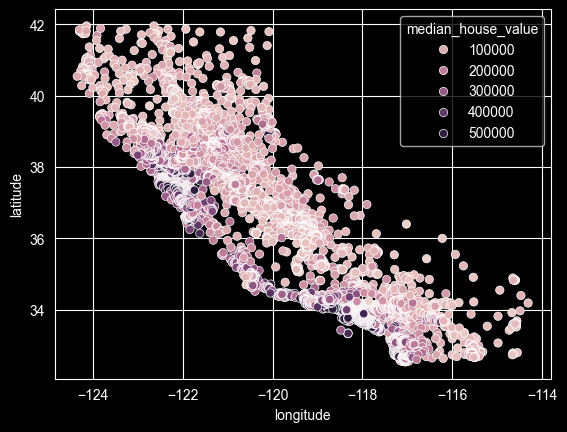

In [26]:
sns.scatterplot(data=df,x="longitude",y="latitude",hue="median_house_value")

In [48]:

train_features =train["rooms_per_house"] = train["total_rooms"] / train["households"]
train_features=train["bedrooms_ratio"] = train["total_bedrooms"] / train["total_rooms"]
train_features=train["people_per_house"] = train["population"] / train["households"]
train_features

C:\Users\Mobina\AppData\Local\Temp\ipykernel_7320\4005040300.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_features =train["rooms_per_house"] = train["total_rooms"] / train["households"]
C:\Users\Mobina\AppData\Local\Temp\ipykernel_7320\4005040300.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_features=train["bedrooms_ratio"] = train["total_bedrooms"] / train["total_rooms"]
C:\Users\Mobina\AppData\Local\Temp\ipykernel_7320\4005040300.py:3: SettingWithCopyWarning: 
A value is trying to

15477    3.919483
10141    2.884956
9191     2.875796
2164     2.527149
8179     2.508475
           ...   
192      4.145455
19424    2.023256
2115     2.835714
7715     2.610759
10239    1.584551
Length: 16512, dtype: float64

In [49]:
train_features


15477    3.919483
10141    2.884956
9191     2.875796
2164     2.527149
8179     2.508475
           ...   
192      4.145455
19424    2.023256
2115     2.835714
7715     2.610759
10239    1.584551
Length: 16512, dtype: float64

In [29]:

df.dropna(axis=0, how="any", inplace=True, subset=["population"])
df.dropna(axis=0, how="any", inplace=True)
df["population"].fillna("median")


0         322.0
1        2401.0
2         496.0
3         558.0
4         565.0
          ...  
20635     845.0
20636     356.0
20637    1007.0
20638     741.0
20639    1387.0
Name: population, Length: 20433, dtype: float64

In [50]:
train_features = train.drop(["median_house_value"],axis = 1)
test_features = test.drop(["median_house_value"],axis = 1)
train_target = train["median_house_value"]
test_target = test["median_house_value"]

In [51]:
train_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 15477 to 10239
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 16512 non-null  float64 
 1   latitude                  16512 non-null  float64 
 2   housing_median_age        16512 non-null  float64 
 3   total_rooms               16512 non-null  float64 
 4   total_bedrooms            16344 non-null  float64 
 5   population                16512 non-null  float64 
 6   households                16512 non-null  float64 
 7   median_income             16512 non-null  float64 
 8   ocean_proximity           16512 non-null  object  
 9   median_income_categories  16512 non-null  category
 10  rooms_per_house           16512 non-null  float64 
 11  bedrooms_ratio            16344 non-null  float64 
 12  people_per_house          16512 non-null  float64 
dtypes: category(1), float64(11), object(1)
memory u

In [19]:
train_features["total_bedrooms"].isnull()
train_features.dropna(subset=["total_bedrooms"], inplace=True)
total_bedrooms_median = train_features["total_bedrooms"].median()
train_features['total_bedrooms'].fillna(total_bedrooms_median, inplace=True)

C:\Users\Mobina\AppData\Local\Temp\ipykernel_7320\3263263763.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_features['total_bedrooms'].fillna(total_bedrooms_median, inplace=True)


In [52]:
train_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 15477 to 10239
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 16512 non-null  float64 
 1   latitude                  16512 non-null  float64 
 2   housing_median_age        16512 non-null  float64 
 3   total_rooms               16512 non-null  float64 
 4   total_bedrooms            16344 non-null  float64 
 5   population                16512 non-null  float64 
 6   households                16512 non-null  float64 
 7   median_income             16512 non-null  float64 
 8   ocean_proximity           16512 non-null  object  
 9   median_income_categories  16512 non-null  category
 10  rooms_per_house           16512 non-null  float64 
 11  bedrooms_ratio            16344 non-null  float64 
 12  people_per_house          16512 non-null  float64 
dtypes: category(1), float64(11), object(1)
memory u

In [53]:
train_features

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_income_categories,rooms_per_house,bedrooms_ratio,people_per_house
15477,-117.18,33.16,15.0,5923.0,1206.0,3943.0,1006.0,3.1793,<1H OCEAN,3,5.887674,0.203613,3.919483
10141,-117.89,33.90,16.0,1426.0,216.0,652.0,226.0,6.5284,<1H OCEAN,5,6.309735,0.151473,2.884956
9191,-118.38,34.30,39.0,1622.0,355.0,903.0,314.0,4.1125,<1H OCEAN,3,5.165605,0.218866,2.875796
2164,-119.82,36.77,36.0,2252.0,468.0,1117.0,442.0,2.9081,INLAND,2,5.095023,0.207815,2.527149
8179,-118.11,33.80,35.0,1034.0,180.0,444.0,177.0,5.4602,<1H OCEAN,4,5.841808,0.174081,2.508475
...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,-122.25,37.79,51.0,175.0,43.0,228.0,55.0,2.1000,NEAR BAY,2,3.181818,0.245714,4.145455
19424,-121.02,37.71,25.0,207.0,41.0,87.0,43.0,3.6023,INLAND,3,4.813953,0.198068,2.023256
2115,-119.72,36.76,23.0,6403.0,NaN,3573.0,1260.0,2.3006,INLAND,2,5.081746,NaN,2.835714
7715,-118.12,33.94,35.0,1813.0,313.0,825.0,316.0,5.2485,<1H OCEAN,4,5.737342,0.172642,2.610759


In [39]:
train_features=pds.DataFrame(train_features).describe()

In [54]:
train_features

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_income_categories,rooms_per_house,bedrooms_ratio,people_per_house
15477,-117.18,33.16,15.0,5923.0,1206.0,3943.0,1006.0,3.1793,<1H OCEAN,3,5.887674,0.203613,3.919483
10141,-117.89,33.90,16.0,1426.0,216.0,652.0,226.0,6.5284,<1H OCEAN,5,6.309735,0.151473,2.884956
9191,-118.38,34.30,39.0,1622.0,355.0,903.0,314.0,4.1125,<1H OCEAN,3,5.165605,0.218866,2.875796
2164,-119.82,36.77,36.0,2252.0,468.0,1117.0,442.0,2.9081,INLAND,2,5.095023,0.207815,2.527149
8179,-118.11,33.80,35.0,1034.0,180.0,444.0,177.0,5.4602,<1H OCEAN,4,5.841808,0.174081,2.508475
...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,-122.25,37.79,51.0,175.0,43.0,228.0,55.0,2.1000,NEAR BAY,2,3.181818,0.245714,4.145455
19424,-121.02,37.71,25.0,207.0,41.0,87.0,43.0,3.6023,INLAND,3,4.813953,0.198068,2.023256
2115,-119.72,36.76,23.0,6403.0,NaN,3573.0,1260.0,2.3006,INLAND,2,5.081746,NaN,2.835714
7715,-118.12,33.94,35.0,1813.0,313.0,825.0,316.0,5.2485,<1H OCEAN,4,5.737342,0.172642,2.610759


In [33]:
train_features_numeric = train_features.select_dtypes(include=np.number)

In [23]:
simple_imputer=sklearn.impute.SimpleImputer(strategy='median')
simple_imputer.fit(train_features_numeric)
numeric_train_features=simple_imputer.transform(train_features_numeric)

In [24]:
simple_imputer.statistics_

array([-1.18250000e+02,  3.49401306e+01,  2.88104809e+01,  2.40539393e+03,
        4.84993423e+02,  1.29400688e+03,  4.53817578e+02,  3.70111315e+00,
        5.32664689e+00,  2.08123580e-01,  3.16653552e+00])

In [60]:
train_features_numeric = pds.DataFrame(simple_imputer.transform(train_features_numeric),
                                      columns = train_features_numeric.columns,
                                      index = train_features_numeric.index)

In [61]:
oe =OrdinalEncoder()

In [62]:
train_features

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_income_categories,rooms_per_house,bedrooms_ratio,people_per_house
15477,-117.18,33.16,15.0,5923.0,1206.0,3943.0,1006.0,3.1793,<1H OCEAN,3,5.887674,0.203613,3.919483
10141,-117.89,33.90,16.0,1426.0,216.0,652.0,226.0,6.5284,<1H OCEAN,5,6.309735,0.151473,2.884956
9191,-118.38,34.30,39.0,1622.0,355.0,903.0,314.0,4.1125,<1H OCEAN,3,5.165605,0.218866,2.875796
2164,-119.82,36.77,36.0,2252.0,468.0,1117.0,442.0,2.9081,INLAND,2,5.095023,0.207815,2.527149
8179,-118.11,33.80,35.0,1034.0,180.0,444.0,177.0,5.4602,<1H OCEAN,4,5.841808,0.174081,2.508475
...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,-122.25,37.79,51.0,175.0,43.0,228.0,55.0,2.1000,NEAR BAY,2,3.181818,0.245714,4.145455
19424,-121.02,37.71,25.0,207.0,41.0,87.0,43.0,3.6023,INLAND,3,4.813953,0.198068,2.023256
2115,-119.72,36.76,23.0,6403.0,NaN,3573.0,1260.0,2.3006,INLAND,2,5.081746,NaN,2.835714
7715,-118.12,33.94,35.0,1813.0,313.0,825.0,316.0,5.2485,<1H OCEAN,4,5.737342,0.172642,2.610759


In [66]:
train_feature_categorical =train_features["ocean_proximity"]

AttributeError: 'Series' object has no attribute 'Dataframe'

In [67]:
oe.fit_transform(pds.DataFrame(train_feature_categorical))

array([[0.],
       [0.],
       [0.],
       ...,
       [1.],
       [0.],
       [0.]], shape=(16512, 1))